# 08 — First Copilot : chargement, structure, qualité

**Objectif** — comprendre First Copilot, l'outil de gestion de réclamations,
distinct d'Intercom, vérifier son intégrité relationnelle et documenter ses
pièges avant toute analyse. Sert de fondation aux notebooks 09 (dédoublonnage
avec le Système A), 10 (analyse propre à B), 11 (validation croisée) et 12
(synthèse consolidée).

| | |
|---|---|
| **Entrée** | 8 fichiers relationnels (`tickets_first.xlsx` + 7 tables liées) |
| **Sorties** | `resultats/tables/08_*.csv` + figures |
| **Suite** | notebook 09 — dédoublonnage A ↔ B |

**Pourquoi un système séparé, plutôt qu'un notebook de plus sur le Système A**
— ce n'est pas le même outil : identifiants UUID propres, modèle relationnel
à 100 % d'intégrité (vérifié ci-dessous), mais des pièges différents de ceux
du CSV Intercom (notebooks 01-03). Ce notebook les documente un par un, avant
qu'ils ne faussent un chiffre en aval — même logique que le notebook 01 pour
le Système A.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, systeme_b, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

tickets = systeme_b.charger_tickets()
categories = systeme_b.charger_categories()
groups = systeme_b.charger_groups()
users = systeme_b.charger_users()
assignations = systeme_b.charger_assignations()
champs, valeurs = systeme_b.charger_champs_personnalises()
conversations = systeme_b.charger_conversations()

print(f"tickets_first          : {len(tickets):,}")
print(f"categories              : {len(categories):,}")
print(f"groups                  : {len(groups):,}")
print(f"users                   : {len(users):,}")
print(f"ticket_assigned_users   : {len(assignations):,}")
print(f"custom_fields           : {len(champs):,}")
print(f"custom_field_values     : {len(valeurs):,}")
print(f"ticket_conversations    : {len(conversations):,}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


tickets_first          : 8,005
categories              : 17
groups                  : 121
users                   : 791
ticket_assigned_users   : 7,572
custom_fields           : 19
custom_field_values     : 50,874
ticket_conversations    : 3,803


## 1. Un système relationnel, pas un fichier plat

```
groups ──< categories ──< tickets_first >── users
                            │  ├─ group_id / source_group_id → groups
                            │  └─ user_id → users
                            ├──< ticket_assigned_users >── users
                            ├──< custom_field_values >── custom_fields
                            └──< ticket_conversations
```

Sept clés à vérifier avant de faire confiance à une seule jointure — vaut
mieux le savoir maintenant qu'après avoir publié un chiffre construit sur une
jointure silencieusement incomplète.

In [2]:
controles = pd.DataFrame(
    [
        {"cle": "tickets.category_id -> categories.id", "orphelins": (~tickets["category_id"].isin(categories["id"])).sum()},
        {"cle": "tickets.group_id -> groups.id", "orphelins": (~tickets["group_id"].dropna().isin(groups["id"])).sum()},
        {"cle": "tickets.source_group_id -> groups.id", "orphelins": (~tickets["source_group_id"].dropna().isin(groups["id"])).sum()},
        {"cle": "tickets.user_id -> users.id", "orphelins": (~tickets["user_id"].dropna().isin(users["id"])).sum()},
        {"cle": "custom_field_values.ticket_id -> tickets.id", "orphelins": (~valeurs["ticket_id"].isin(tickets["id"])).sum()},
        {"cle": "custom_field_values.custom_field_id -> custom_fields.id", "orphelins": (~valeurs["custom_field_id"].isin(champs["id"])).sum()},
        {"cle": "ticket_conversations.ticket_id -> tickets.id", "orphelins": (~conversations["ticket_id"].isin(tickets["id"])).sum()},
        {"cle": "ticket_assigned_users.ticket_id -> tickets.id", "orphelins": (~assignations["ticket_id"].isin(tickets["id"])).sum()},
        {"cle": "ticket_assigned_users.user_id -> users.id", "orphelins": (~assignations["user_id"].isin(users["id"])).sum()},
    ]
).set_index("cle")
chargement.sauver_table(controles, "08_integrite_referentielle")
controles

  -> resultats/tables/08_integrite_referentielle.csv


,orphelins
cle,
tickets.category_id -> categories.id,0
tickets.group_id -> groups.id,0
tickets.source_group_id -> groups.id,0
tickets.user_id -> users.id,0
custom_field_values.ticket_id -> tickets.id,0
custom_field_values.custom_field_id -> custom_fields.id,0
ticket_conversations.ticket_id -> tickets.id,0
ticket_assigned_users.ticket_id -> tickets.id,0
ticket_assigned_users.user_id -> users.id,0


**Zéro orphelin sur les neuf clés.** Contraste net avec le Système A, où
39 colonnes sur 67 sont inexploitables et où le fil de conversation est
tronqué à l'extraction (notebook 01) — ce système-ci a été exporté proprement.
Ce qui manque côté B n'est donc pas un problème d'export mais un problème de
**saisie** (colonnes vides ou constantes, §3) : une distinction qui compte
pour savoir quoi redemander, et à qui.

## 2. Catégories et agences — deux dimensions absentes du Système A

In [3]:
cat = tickets["category_id"].value_counts().rename("effectif").to_frame()
cat = cat.join(categories.set_index("id")["name"]).set_index("name")
cat["pct"] = (cat["effectif"] / len(tickets) * 100).round(1)
chargement.sauver_table(cat[["effectif", "pct"]], "08_categories")
cat[["effectif", "pct"]]

  -> resultats/tables/08_categories.csv


,effectif,pct
name,,
SARA,4992,62.4
CARTE,1387,17.3
MAC,640,8.0
COMPTE,452,5.6
AUTRE,286,3.6
SARA_FONCTIONNEL,72,0.9
CREDIT,53,0.7
ACCUEIL,26,0.3
EFIRST,23,0.3


`source_group_id` (88 valeurs) mélange deux choses différentes : des agences
physiques (`groups.group_name` commençant par `FIRST_BANK_`) et des services
internes (`DIRECTION_CONTROLE_PERMANENT`, `DIRECTION_RECHERCHE_INNOVATION`,
`AGENT_PUBLICATION`...). Les distinguer avant de lire ce champ comme « une
dimension géographique » — sinon le plus gros volume apparent est un service
de contrôle interne, pas une agence.

In [4]:
noms_groupes = tickets["source_group_id"].map(groups.set_index("id")["group_name"])
est_agence = noms_groupes.str.startswith("FIRST_BANK_", na=False)
tickets["origine"] = noms_groupes.where(est_agence, "(direction / service interne)")

origine = tickets["origine"].value_counts().rename("effectif").to_frame()
origine["pct"] = (origine["effectif"] / len(tickets) * 100).round(1)
chargement.sauver_table(origine.head(20), "08_origine_groupes")

nb_agences_catalogue = groups["group_name"].str.startswith("FIRST_BANK_", na=False).sum()
print(f"Tickets rattachés à une agence (FIRST_BANK_*) : {est_agence.sum():,} ({est_agence.mean() * 100:.1f} %)")
print(f"Agences distinctes au catalogue                : {nb_agences_catalogue}")
origine.head(12)

  -> resultats/tables/08_origine_groupes.csv
Tickets rattachés à une agence (FIRST_BANK_*) : 2,958 (37.0 %)
Agences distinctes au catalogue                : 97


,effectif,pct
origine,,
(direction / service interne),5047,63.0
FIRST_BANK_NGAOUNDERE,277,3.5
FIRST_BANK_HIPPODROME,270,3.4
FIRST_BANK_MESSAMENDONGO,109,1.4
FIRST_BANK_KRIBI,108,1.3
FIRST_BANK_FENETRE_ISLAMIQUE_YAOUNDE,104,1.3
FIRST_BANK_DSCHANG,99,1.2
FIRST_BANK_MAROUA,90,1.1
FIRST_BANK_NDOKOTTI,87,1.1


## 3. Colonnes à écarter — vides, constantes, ou sans pouvoir discriminant

Même discipline que le notebook 01 pour le Système A : une colonne
inexploitable est **listée**, pas silencieusement absente des tables de
contrôle.

In [5]:
controles_colonnes = systeme_b.controles_qualite(tickets)
chargement.sauver_table(controles_colonnes, "08_colonnes_ecartees", index=False)
controles_colonnes

  -> resultats/tables/08_colonnes_ecartees.csv


,colonne,pct_rempli,nb_uniques,raison_ecartee
0,type_reclamation,0.0,0,vide à 100 %
1,is_reclamation_fondee,0.0,0,vide à 100 %
2,customer_id,0.0,0,vide à 100 % — aucun identifiant client exploitable dans ce système
3,creator_type,100.0,1,constante ('EMPLOYEE')
4,domaine_reclamation,72.0,1,"quasi-constante ('RECLAMATION_CLIENT', 72 % de remplissage)"
5,detail,4.2,235,"remplie à 4,2 % seulement"
6,priority,100.0,4,"à 97,5 % 'MOYENNE' — valeur par défaut jamais modifiée"


## 4. Le piège du délai : `created → closed` n'est pas un délai de traitement

`closed_on` existe et semble utilisable — jusqu'à ce qu'on le compare à
`resolved_on`.

In [6]:
delai_resolu_j = systeme_b.delai_resolution(tickets) / 24  # heures -> jours
delai_ferme_j = (tickets["closed_on"] - tickets["resolved_on"]).dt.total_seconds() / 86400
memes_dates = (tickets["closed_on"] == tickets["updated_at"]).sum()

print(f"created -> resolved : médiane {delai_resolu_j.median():.1f} j  (n={delai_resolu_j.notna().sum():,}) — fiable")
print(f"resolved -> closed  : médiane {delai_ferme_j.median():.1f} j  (n={delai_ferme_j.notna().sum():,})")
print(f"closed_on == updated_at : {memes_dates:,} / {tickets['closed_on'].notna().sum():,} clôtures")

created -> resolved : médiane 9.1 j  (n=6,010) — fiable
resolved -> closed  : médiane 61.0 j  (n=5,118)
closed_on == updated_at : 5,552 / 5,974 clôtures


  -> resultats/figures/08_delai_cloture_artefact.png


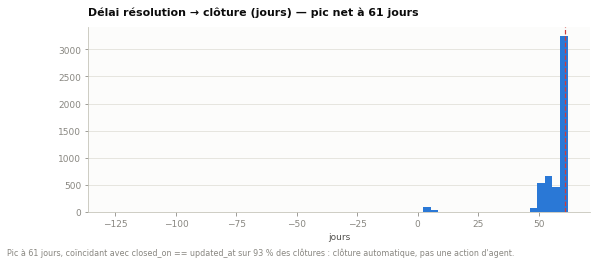

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(delai_ferme_j.dropna(), bins=60, color=viz.SERIES[0])
ax.axvline(61, color=viz.STATUT["critique"], linestyle="--", linewidth=1.2)
ax.set_title("Délai résolution → clôture (jours) — pic net à 61 jours")
ax.set_xlabel("jours")
ax.grid(axis="x", visible=False)
viz.annoter_source(
    fig,
    "Pic à 61 jours, coïncidant avec closed_on == updated_at sur 93 % des clôtures : "
    "clôture automatique, pas une action d'agent.",
)
viz.sauver(fig, "08_delai_cloture_artefact")
plt.show()

**Conclusion retenue pour la suite du projet** : tout délai de traitement
publié à partir de First Copilot utilise `created_at → resolved_on`
(`systeme_b.delai_resolution`), jamais `closed_on`. Ce dernier ne mesure que
le rythme d'un job de clôture automatique fixé à ~61 jours, pas le travail des
agents.

## 5. Les 3 dropdowns de sous-motif — une taxonomie déjà annotée

C'est l'élément le plus utile de ce système pour la suite de l'étude : une
qualification de motif faite à la main, ticket par ticket, sans ambiguïté
(un seul dropdown rempli par ticket, jamais deux valeurs contradictoires,
vérifié ci-dessous) — exactement le type de jeu de référence que le protocole
attend encore côté Système A (§4.5).

In [8]:
sm = systeme_b.sous_motifs(champs, valeurs)
doublons = sm.groupby(level=0).size()

print(f"Tickets qualifiés par un dropdown de sous-motif : {len(sm):,} / {len(tickets):,} ({len(sm) / len(tickets) * 100:.1f} %)")
print(f"Tickets avec plus d'un dropdown renseigné (devrait être 0) : {(doublons > 1).sum()}")

resume_sm = sm.groupby(["domaine", "sous_motif"]).size().rename("effectif").reset_index()
resume_sm["pct_domaine"] = resume_sm.groupby("domaine")["effectif"].transform(lambda s: (s / s.sum() * 100).round(1))
resume_sm = resume_sm.sort_values(["domaine", "effectif"], ascending=[True, False])
chargement.sauver_table(resume_sm, "08_sous_motifs", index=False)
resume_sm

Tickets qualifiés par un dropdown de sous-motif : 6,221 / 8,005 (77.7 %)
Tickets avec plus d'un dropdown renseigné (devrait être 0) : 0
  -> resultats/tables/08_sous_motifs.csv


,domaine,sous_motif,effectif,pct_domaine
4,Sous domaine Monetique,Opérations GAB AFB,705,54.1
3,Sous domaine Monetique,Opérations GAB,294,22.6
0,Sous domaine Monetique,Autre,92,7.1
8,Sous domaine Monetique,Versement GAB,75,5.8
7,Sous domaine Monetique,Paiement En Ligne,71,5.4
5,Sous domaine Monetique,Opérations GAB Confrère,41,3.1
6,Sous domaine Monetique,Opérations TPE,22,1.7
1,Sous domaine Monetique,Carte Blanche,2,0.2
2,Sous domaine Monetique,Carte Volée,1,0.1
11,Sous domaine Operations bancaire,Problème Cash Deposit,129,32.9


## 6. Montants et dates de transaction — anomalies à traiter, meilleure couverture que A

Le champ montant est renseigné à 92,7 % des tickets côté B contre 39,96 %
côté A (protocole §3.4) — mais il porte les mêmes types d'anomalies
(négatifs, zéros, valeurs extrêmes) et appelle la même réserve : **ordre de
grandeur, jamais un chiffre officiel** (même principe que
`chargement.montants_plausibles`, `config.MONTANT_PLAFOND_PLAUSIBLE`).

In [9]:
m = systeme_b.montants(champs, valeurs)
mp = systeme_b.montants_plausibles(champs, valeurs)

print(f"Champ 'Montant en XAF' présent (valeur brute, avant conversion) : {len(m):,} / {len(tickets):,} tickets ({len(m) / len(tickets) * 100:.1f} %)")
print(f"  dont convertibles en nombre : {m.notna().sum():,} ({m.notna().sum() / len(tickets) * 100:.1f} % des tickets, "
      f"{m.notna().mean() * 100:.1f} % de ceux qui ont une valeur)")
print(f"  négatifs : {(m < 0).sum()}   zéros : {(m == 0).sum()}   "
      f"au-delà du seuil plausible ({config.MONTANT_PLAFOND_PLAUSIBLE_B:,.0f} XAF) : {(m >= config.MONTANT_PLAFOND_PLAUSIBLE_B).sum()}")
print(f"Montants plausibles : {len(mp):,}   médiane {mp.median():,.0f} XAF")

dt = systeme_b.dates_transaction(champs, valeurs)
aberrantes = (dt > pd.Timestamp.now()) | (dt < pd.Timestamp("2020-01-01"))
print(f"\nDate de transaction renseignée : {dt.notna().sum():,} / {len(tickets):,}")
print(f"  dont aberrantes (avant 2020 ou dans le futur) : {aberrantes.sum():,}")

Champ 'Montant en XAF' présent (valeur brute, avant conversion) : 7,588 / 8,005 tickets (94.8 %)
  dont convertibles en nombre : 7,419 (92.7 % des tickets, 97.8 % de ceux qui ont une valeur)
  négatifs : 1   zéros : 44   au-delà du seuil plausible (10,000,000 XAF) : 31
Montants plausibles : 7,343   médiane 70,150 XAF

Date de transaction renseignée : 6,818 / 8,005
  dont aberrantes (avant 2020 ou dans le futur) : 9


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/systeme_b.py:253: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  return pd.to_datetime(d, errors="coerce", dayfirst=True)


## 7. Canal, statut et volume mensuel

Le canal `INTERCOM` est **inclus** ici : le dédoublonnage avec le Système A
n'est pas fait dans ce notebook, c'est tout l'objet du notebook 09. Tout
chiffre de ce notebook 08 porte donc sur les 8 005 tickets de B, sans
retirer les doublons potentiels avec A.

In [10]:
canal = tickets["canal"].value_counts().rename("effectif").to_frame()
canal["pct"] = (canal["effectif"] / len(tickets) * 100).round(1)
statut = tickets["status"].value_counts().rename("effectif").to_frame()
statut["pct"] = (statut["effectif"] / len(tickets) * 100).round(1)

chargement.sauver_table(canal, "08_canaux")
chargement.sauver_table(statut, "08_statuts")

print("Canal :")
print(canal)
print("\nStatut :")
print(statut)

  -> resultats/tables/08_canaux.csv
  -> resultats/tables/08_statuts.csv
Canal :
           effectif   pct
canal                    
INTERCOM       3180  39.7
EN_AGENCE      2082  26.0
COURRIER       1031  12.9
APPEL           498   6.2
COLLEGUE        345   4.3
MAIL            305   3.8
AUTRE           301   3.8
WHATSAPP        258   3.2

Statut :
                           effectif   pct
status                                   
FERME                          5968  74.6
RESOLU                          889  11.1
TRANSFERE_POUR_TRAITEMENT       727   9.1
OUVERT                          234   2.9
EN_COURS                        187   2.3


  -> resultats/tables/08_volume_mensuel.csv


  -> resultats/figures/08_volume_mensuel_b.png


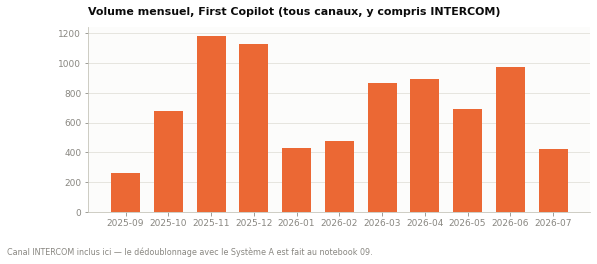

In [11]:
vol = tickets.groupby("mois").size()
chargement.sauver_table(vol.rename("effectif").to_frame(), "08_volume_mensuel")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar([str(m) for m in vol.index], vol.to_numpy(), color=viz.SERIES[1], width=0.68)
ax.set_title("Volume mensuel, First Copilot (tous canaux, y compris INTERCOM)")
ax.grid(axis="x", visible=False)
viz.annoter_source(
    fig,
    "Canal INTERCOM inclus ici — le dédoublonnage avec le Système A est fait au notebook 09.",
)
viz.sauver(fig, "08_volume_mensuel_b")
plt.show()

## Ce que ce notebook établit

1. First Copilot est **relationnellement propre** (0 orphelin sur 9 clés) —
   ce qui manque est un problème de saisie, pas d'export.
2. Il porte deux dimensions absentes du Système A : la catégorie fine
   (17 valeurs, dont 78 % des tickets qualifiés par un des 3 dropdowns de
   sous-motif) et l'agence d'origine (88 groupes, dont une majorité de
   services internes à distinguer des agences réelles).
3. `closed_on` est un piège : n'utiliser que `created_at → resolved_on` pour
   tout délai de traitement.
4. Il tourne **en parallèle** du Système A sur toute la période opérationnelle
   (nov. 2025 → juil. 2026), canal `INTERCOM` inclus — la question du
   recouvrement entre les deux systèmes n'est pas encore traitée ici.

**Suite** : notebook 09 — établir si, et dans quelle mesure, B duplique A.